## Background
The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

The equivalence is as follows (and a brief derivation will be detailed at a later time):

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} + \mathcal{G}^{\text{(num)}} = \mathcal{G}^{\text{(mix)}}
\end{equation}
$$

We have two separate methods for calculating $\mathcal{G}^{\text{(mix)}}$: using the convergence of a diffusive flux $\mathcal{F}$, or by using the tracer variance decay rate $\chi$. It then follows that 

$$
\begin{align}
     \mathcal{G}_\mathcal{F}^{\text{(phy)}} + \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \mathcal{G}_\mathcal{F}^{\text{(mix)}} = \mathcal{G}^{\text{(mix)}} \\
     \mathcal{G}_\chi^{\text{(phy)}} + \mathcal{G}_\chi^{\text{(num)}} &= \mathcal{G}_\chi^{\text{(mix)}} = \mathcal{G}^{\text{(mix)}}\\
     \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} &= \mathcal{G}_\chi^{\text{(phy)}} \\
     \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \mathcal{G}_\chi^{\text{(num)}} 
\end{align}
$$

The actual calculations for $\mathcal{G}_\mathcal{F}^{\text{(mix)}}$ and $\mathcal{G}_\chi^{\text{(mix)}}$ are as follows.
### $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ 

>- use the tracer mass tendency output `salinityVertMixTendency` $= \mathcal{F} = -\nabla \cdot \left(-\kappa_{phy}\nabla \lambda \right)$ for $\kappa_{phy} = 10^{-5} \, m^2 s^{-1}$ (set by KPP; vertical mixing is parameterized in this simulation), and where $\lambda$ is the tracer (salinity, in this case).
>- $\Omega(\tilde\lambda, t)$ represents the volume defining the water mass $\mathcal{M}_\geq$

$$
\begin{equation}
    \mathcal{G}_\mathcal{F}^\text{(phy)} = \frac{\partial}{\partial \lambda} \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \, \text{d}V
\end{equation}
$$

### $\mathcal{G}_\mathcal{F}^{\text{(num)}}$ 
>- We cannot directly calculate $\mathcal{F}^{\text{(num)}}$
>- Instead, we can calculate as the residual of the water mass transformation budget, given a known $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$.
>- This works in this idealized simulation because we know that there is no surface tracer flux $\mathcal{S}$ (`salinitySurfaceFluxTendency` = 0 $\forall \, \mathbf{x}, t$), and there is no transport ($\Psi=0$) if we define the region $\mathcal{R}$ to be the entire domain such that boundary of the water mass $\mathcal{M}_\geq$ is the isosurface $\mathcal{A_R}$.

$$
\begin{align}
    \partial_t \mathcal{M}_\geq &= \Psi + \mathcal{S} + \mathcal{G}_\mathcal{F}^{\text{(phy)}} + \mathcal{G}_\mathcal{F}^{\text{(num)}} \\
    \implies \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \partial_t \mathcal{M}_\geq - \mathcal{G}_\mathcal{F}^{\text{(phy)}}
\end{align}
$$

### $\mathcal{G}_\chi^{\text{(phy)}}$ 
>- use the tracer variance decay rate `chiPhyVerSalt_center` $= \chi^{\text{(phy)}} = -2 \kappa_{phy} \left( \frac{\partial \lambda}{\partial z}\right)^2 $.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = -\frac{1}{2} \partial_\lambda^2 \int_{\Omega(\tilde\lambda,t} \rho \chi^{\text{(phy)}} \, \text{d}V
\end{equation}
$$

### $\mathcal{G}_\chi^{\text{(num)}}$ 
>- We can calculate `chiSpurSaltBR08` $= \chi^{\text{(num)}}$ using the discrete variance decay algorithm

$$
\begin{equation}
    \chi^{\text{(num)}} = 2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}
\end{equation}
$$
>- where $\kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x} \right)$ (from algorithm)
>- We can then calculate $\mathcal{G}_\chi^{\text{(num)}}$  as

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(num)}} = -\frac{1}{2} \partial_\lambda^2 \int_{\Omega(\tilde\lambda,t} \rho \chi^{\text{(num)}} \, \text{d}V
\end{equation}
$$

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

## Open files & visualize raw data

Note that we will be finite-differencing mass = `density * layerThickness` over time to get the mass evolution for the LHS of the budget equation. This means that we are actually calculating $\partial_t \mathcal{M}_\geq$ at time $t=i+1/2$, rather than at $t = i$ when we calculate using snapshots in time `ss_ds_output`. As a result, we also want our diagnostic variables $\mathcal{G}^{\text{(mix)}}$ to sit on the $i+1/2$ time interval. To achieve, this, we output the time-averaged datavariables `avg_ds_output` (see `avg-ds_output.Time`). 

In [2]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeCustom' in i:
            new_name = i.replace('timeCustom_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

In [109]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# averaged values (time = 10*n + 5)
avg_ds_output = xr.open_dataset(filepath + '/analysis_members/mpaso.hist.am.timeSeriesStatsCustomAvg_10km_channel.0001-01-01.nc',decode_times=False)

# rename variables to remove the "timeCustom_avg" and "activeTracer__" prefixes
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   periodic = False, 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' ,boundary = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', boundary = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', boundary = 'extend')


# snapshots at every timestep (dt = 10 mins)
ss_ds_output = xr.open_dataset(filepath + '10km_channel_output.nc',decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   periodic = False, 
                   autoparse_metadata = False)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', boundary = 'extend')

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

time_idx = 500

In [4]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'

# # remove the first time step to match time indices with DVD
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc').isel(Time=slice(1,None))
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

# # # format ds_dvd so that it includes a time=0 index (otherwise missing first time step)
# # ds_dvd = xr.concat([ds_dvd.isel(Time=0), ds_dvd],dim='Time')
# # ds_dvd["xtime"][0]= np.array(b"0001-01-01_00:00:00", dtype="|S64")


# # interpolate the DVD vertical physical mixing onto nVertLevels
# grid_dvd = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
#                         periodic = False, 
#                         autoparse_metadata=False)
# ds_dvd['chiPhyVerTemp_center'] = grid_dvd.interp(ds_dvd.chiPhyVerTemp, 'Z' ,boundary = 'extend')
# ds_dvd['chiPhyVerSalt_center'] = grid_dvd.interp(ds_dvd.chiPhyVerSalt, 'Z', boundary = 'extend')

# # ffill (good practice but not applicable here because no bathymetry)
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
# ds_output['xtime'] = ds_output.xtime.assign_attrs(description='Removed time=0')

# # # merge datasets
# # ds_output = xr.merge([ds_dvd, ds_output])

# # # set time index
# # time_idx = 115

In [5]:
for i in avg_ds_output.data_vars:
    if 'BR08' in i:
        print(i)

chiSpurTempBR08
chiSpurSaltBR08


In [6]:
for i in avg_ds_output.data_vars:
    if 'urface' in i:
        print(i)

temperatureSurfaceFluxTendency
salinitySurfaceFluxTendency


In [110]:
ss_ds_output

<xarray.Dataset> Size: 1GB
Dimensions:                    (Time: 1729, nCells: 340, nVertLevels: 50,
                                nVertLevelsP1: 51)
Coordinates:
  * nVertLevelsP1              (nVertLevelsP1) int64 408B 0 1 2 3 ... 48 49 50
Dimensions without coordinates: Time, nCells, nVertLevels
Data variables:
    xtime                      (Time) |S64 111kB ...
    layerThickness             (Time, nCells, nVertLevels) float32 118MB ...
    density                    (Time, nCells, nVertLevels) float32 118MB ...
    potentialDensity           (Time, nCells, nVertLevels) float32 118MB ...
    temperature                (Time, nCells, nVertLevels) float32 118MB ...
    salinity                   (Time, nCells, nVertLevels) float32 118MB 15.2...
    passiveTemperature         (Time, nCells, nVertLevels) float32 118MB ...
    passiveSalinity            (Time, nCells, nVertLevels) float32 118MB ...
    passiveTemperatureSquared  (Time, nCells, nVertLevels) float32 118MB ...
    passiveSalinitySquared     (Time, nCells, nVertLevels) float32 118MB ...
    salinity_P1                (Time, nCells, nVertLevelsP1) float32 120MB 15...
Attributes: (12/1365)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     unknown
    on_a_sphere:                                                     NO
    ...                                                              ...
    config_rx1_slope_weight:                                         0.1
    config_rx1_zstar_weight:                                         1.0
    config_rx1_horiz_smooth_open_ocean_cells:                        20
    config_rx1_min_levels:                                           3
    config_rx1_min_layer_thickness:                                  1.0
    file_id:                                                         zft4kulb7k

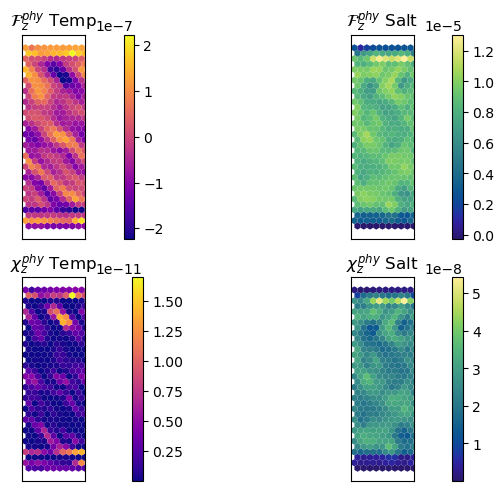

In [111]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, avg_ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
b = mosaic.polypcolor(ax[0,1],descriptor, avg_ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline')
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, avg_ds_output.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
d = mosaic.polypcolor(ax[1,1],descriptor, avg_ds_output.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline')
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

## Explanation of data

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

*I think this is what also eliminates the negative sign in $\mathcal{G}^{\text{(phy)}}$.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class.

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

### Note these are slightly different signs than the earlier equation box. This is because of how we defined $\mathcal{M}_\ge$, which adds a negative sign, since we are interested in how water is being transformed into masses with $\lambda > \tilde\lambda$... I think (6/30/26)

### Non-generalized functions for calculating $\mathcal{G}^\text{(phy)}$

In [112]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    tendency = ds_output[F_variable] * dV

    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels

    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

    # recall that we define the mass to be M>=, so we need to take the cumulative sum from bottom to top to get 
    # the full mixing per salinity class, which means the mixing for \tilde\lambda surfaces AND all \lambda surfaces greater than \tilde\lambda
    
    # reverse the direction of salinity_P1 (now greatest to lowest)
    # then take the cumulative sum of tendency from greatest salinity to lowest salinity 
    # then reverse the direction of salinity_P1 again 
    da_F_volume_int_tendency_transformed  = da_F_tendency_transformed.isel(salinity_P1 = 
                                                                          slice(None, None, -1)).cumsum(dim='salinity_P1').isel(salinity_P1 = 
                                                                                                                                slice(None, None, -1))

    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    # the transform remapped the datavariable to the CENTER of the cell 
    # rename the salinity_P1 coords to salinity
    ds_F_volume_int_tendency_transformed = ds_F_volume_int_tendency_transformed.rename({'salinity_P1' : 'salinity'})
    
    # add back the salinity_P1 coordinates
    ds_F_volume_int_tendency_transformed = ds_F_volume_int_tendency_transformed.assign_coords({'salinity_P1' : target_coords_P1})
    
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

    # then calculate the derivative d_integrand
    # create an array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords_P1) - 2):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed[
                                    'cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed[
                                    'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = (d_tracerMassFlux / dlambda) * -1e3 # salinityMixTendency has units of 1e-3 / s, need to convert to compare
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # this eliminates the first and last entry in salinity_P1 coords
    salinity_P1_trimmed = target_coords_P1[1:-1]
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    
    # add back salinity_coords
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    
    G_F_phy_ds = G_F_phy_ds.assign_coords({'salinity' : salinity_trimmed})

    # remap to get onto matching salinity coordinates
    # make a grid that identifies salinity as the vertical coordinates
    grid_salinity = Grid(G_F_phy_ds, coords={'Z': {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        periodic = False,
                        autoparse_metadata = False)
    
    G_F_phy_ds['G_F_phy_center'] = grid_salinity.interp(G_F_phy_ds.G_F_phy, 'Z', boundary='extend')
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])

    return G_F_phy_ds

In [113]:
# rho_0 = 1026
# target_coord_spacing = 0.25
# # your chi_variable should sit on cell centers
# chi_variable = 'chiPhyVerSalt_center'

def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print('Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print('Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * mesh.layerThickness.isel(Time=0)
    
    tendency = rho_0 * ds_output[chi_variable] * dV
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # +2 to ensure that the upper and lower bins have Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # transform chi data from nVertLevels coord to salinity coord
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                periodic = False,
                autoparse_metadata = False)
    
    da_chi_tendency_transformed = grid.transform(tendency, # currently sitting on cell centers
                                                  'Z',
                                                  target_coords_P1, # consersvative remap requires specifying target edge coords
                                                  method = 'conservative',
                                                  target_data = ds_output.salinity_P1)  # corresponding actual coords to be binned in target_coords)
    
    # recall that we define the mass to be M>=, so we need to take the cumulative sum from bottom to top to get 
    # the full mixing per salinity class, which means the mixing for \tilde\lambda surfaces AND all \lambda surfaces greater than \tilde\lambda
    
    # reverse the direction of salinity_P1 (now greatest to lowest)
    # then take the cumulative sum of tendency from greatest salinity to lowest salinity 
    # then reverse the direction of salinity_P1 again 
    da_chi_volume_int_tendency_transformed  = da_chi_tendency_transformed.isel(salinity_P1 = 
                                                                          slice(None, None, -1)).cumsum(dim='salinity_P1').isel(salinity_P1 = 
                                                                                                                                slice(None, None, -1))

    # convert from dataarray to dataset
    ds_chi_volume_int_tendency_transformed = da_chi_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + chi_variable)
    
    # transform remapped the datavariable to the CENTER of the cell
    # rename the salinity_P1 coords to salinity
    ds_chi_volume_int_tendency_transformed = ds_chi_volume_int_tendency_transformed.rename({'salinity_P1' : 'salinity'})

    # # check the transformation 7/7
    # diff = ds_chi_volume_int_tendency_transformed.sum() - tendency.sum()
    # if diff > 10:
    #     print('not conserved')
    # else:
    #     print('conserved')
    
    # calculate the first derivative (d_integrand / d_lambda)
    mixingFlux = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i - i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    for i in range(0,len(target_coords_P1)-2):
        d_mixing = ds_chi_volume_int_tendency_transformed[
                    'cumulative_vol_int_tendency_' + chi_variable][:,:,i] - ds_chi_volume_int_tendency_transformed[
                    'cumulative_vol_int_tendency_' + chi_variable][:,:,i+1]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class 
        mixingFlux.append(d_mixing_d_lambda)
    
    # convert mixingFlux to dataarray
    mixingFlux_da = xr.concat(mixingFlux, dim='salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingFlux_da[i,:,:] - mixingFlux_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})

    return G_chi_mix_ds

In [114]:
# wrapper function to perform all calculations
def calculate_G_mix(rho_0, mesh, ds_output, target_coord_spacing = 1):
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, ds_output,target_coord_spacing)
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, ds_output,target_coord_spacing)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    G_phy_comp_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds

In [115]:
# calculate transformation at every density class
def vertical_cumsum(G_phy_ds, variable, reduce_time_dim_method, time_idx=0):

    if reduce_time_dim_method == 'average':
        G_phy = G_phy_ds[variable].mean(dim='Time').sum(dim='nCells')

    if reduce_time_dim_method == 'isel':
        G_phy = G_phy_ds[variable].isel(Time = time_idx).sum(dim='nCells')
        
    # cumsum from bottom (lowest salinity class) to top (highest salinity class)
    # we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
    # reduce G_phy_ds along several dimensions
    
    rev_G_phy = np.flipud(G_phy)
    cumsum_rev_G_phy = np.cumsum(rev_G_phy)
    # reverse back to match highest salinity value to lowest cumsum value
    cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

    print('reduced time dimension by ', reduce_time_dim_method)
    if reduce_time_dim_method == 'isel':
        print('time_idx = ', time_idx)

    return G_phy, cumsum_G_phy

In [116]:
## figure out at what salinity are the minima and maxima located for G_F_phy and G_chi_phy

def find_min_max_idx(da):
    # max if G_i > G_i+1 and G_i > G_i-1
    maxima_indices = np.where((da[1:-1] > da[:-2]) & (da[1:-1] > da[2:]))[0] + 1
    print('maxima at ', da[maxima_indices])
    
    # min if G_i < G_i+1 and G_i < Gi-1
    minima_indices = np.where((da[1:-1] < da[:-2]) & (da[1:-1] < da[2:]))[0] + 1
    print('minima at ' , da[minima_indices])

    return maxima_indices, minima_indices

-------
--------

In [117]:
rho_0 = 1026
target_coord_spacing = 0.5

G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, G_phy_comp_ds = calculate_G_mix(rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_chi_phy
Calculating G_chi_num


In [118]:
# find dM/dt
# create grid to allow for transformation to salinity coords
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# +2 to ensure that the upper and lower bins have Gphy = 0

lower_bound = avg_ds_output.salinity_P1.min() - 2
upper_bound = avg_ds_output.salinity_P1.max() + 2
target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

# grid_nVertLevels = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
#                             periodic = False, 
#                             autoparse_metadata=False)

# mass of every grid cell in z coords
mass = ss_ds_output.density * ss_ds_output.layerThickness * mesh.areaCell
# then remap into salinity space
# calculate salinity_P1 values

mass_transform = ss_ds_grid.transform(mass,
                                      'Z',
                                      target_coords_P1,
                                      method = 'conservative',
                                      target_data = ss_ds_output.salinity_P1)

mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})

# then calculate then vertical cumulative sum
vert_int_mass = mass_transform.isel(salinity = slice(None,None,-1)).cumsum(dim='salinity').isel(salinity = slice(None,None,-1))

In [119]:
# target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
# density_transform = grid_nVertLevels.transform(ds_output.density,
#                                             'Z',
#                                             target_coords,
#                                             method = 'linear',
#                                             target_data = ds_output.salinity)

# layerThickness_transform = grid_nVertLevels.transform(ds_output.layerThickness,
#                                             'Z',
#                                             target_coords,
#                                             method = 'linear',
#                                             target_data = ds_output.salinity)

# mass_transform = density_transform * mesh.areaCell * layerThickness_transform
# vert_int_mass = mass_transform.isel(salinity = slice(None,None,-1)).cumsum(dim='salinity').isel(salinity = slice(None,None,-1))

In [120]:
# calculate dM>= / dt
# take the sum of vertical cumsums (all mass below the surface for all nCells)
dM = vert_int_mass[1:,:,:] - vert_int_mass[:-1,:,:]

dt = 2 * 60 * 60 # dt = 2 hrs, need to get into units of seconds
dM_dt = (dM / dt).transpose('salinity','nCells','Time')

# from dM/dt, calculate the residual numerical mixing
G_F_num = dM_dt - G_phy_comp_ds.G_F_phy_center

In [121]:
(mesh.layerThickness * mesh.areaCell).isel(Time=0).sum() - (ss_ds_output.layerThickness * mesh.areaCell).isel(Time = 0).sum()

<xarray.DataArray ()> Size: 8B
array(0.)

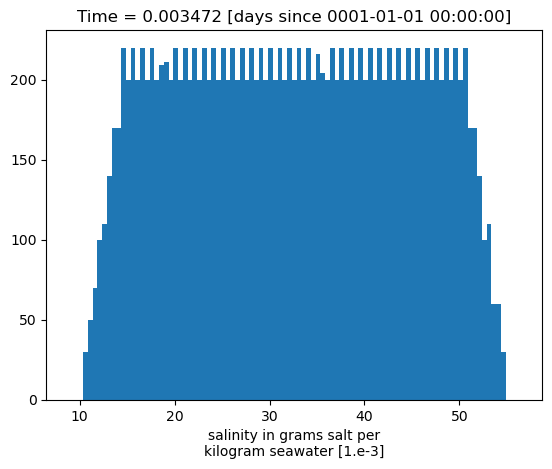

In [122]:
avg_ds_output.salinity.isel(Time=0).plot.hist(bins = target_coords);

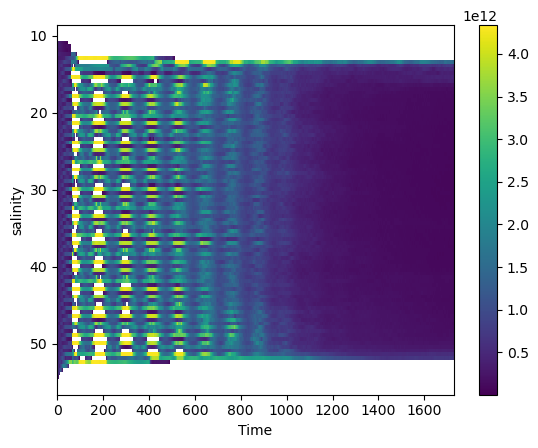

In [123]:
mass_transform.mean(dim='nCells').plot(y='salinity')
plt.gca().invert_yaxis()

Text(0, 0.5, 'Mass')

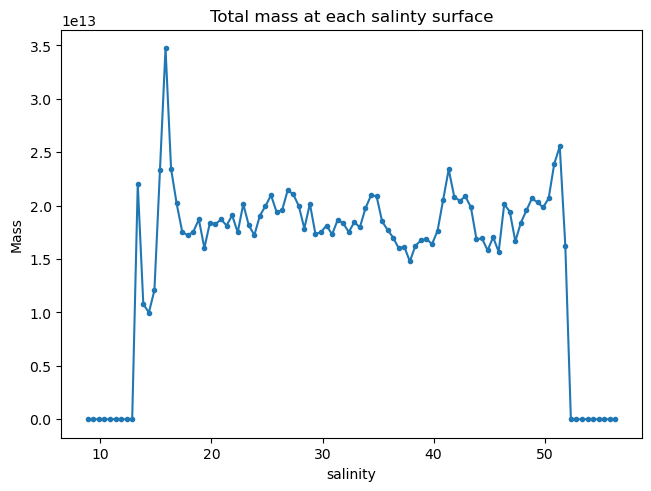

In [124]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
mass_transform.sum(dim='nCells').isel(Time=-1).plot(marker='.')
ax.set_title('Total mass at each salinty surface')
ax.set_ylabel('Mass')

Text(0, 0.5, 'Mass')

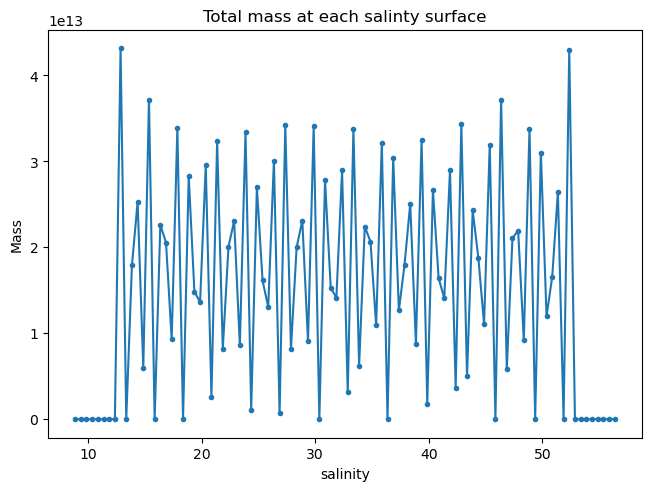

In [125]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)
mass_transform.sum(dim='nCells').isel(Time=100).plot(marker='.')
ax.set_title('Total mass at each salinty surface')
ax.set_ylabel('Mass')

In [126]:
S_0 = 15 #g/kg
M_squared = 10**(-6) # 1/s^2
beta = 0.76 # 
grav = 9.80665 # m/s^2
rho = 1000 # kg/m^3
ymid_minus_half = mesh.yCell - ((mesh.yCell.min().values - mesh.yCell.max().values) / 2)

# S_0 + M_squared / beta / grav * rho * ymid_minus_half

In [127]:
S_0 = 15 #g/kg
M_squared = 10**(-6) # 1/s^2
beta = 7.6*10**(-4) # 
grav = 9.80665 # m/s^2
rho = 1026 # kg/m^3
ymid_minus_half = mesh.yCell - ((mesh.yCell.min().values - mesh.yCell.max().values) / 2)

In [128]:
# what is in the salinity field initialization code
dylans = S_0 + M_squared / beta / grav * rho * ymid_minus_half

# salinity field initialization code written out to make sense mathematically
dylans_cleaned = S_0 + (M_squared / (beta * grav)) * (rho * ymid_minus_half)

# written out to match what is written in kyle's paper.
paper = S_0 + (M_squared / (beta * grav * rho)) * ymid_minus_half

In [129]:
def new_S(ds, mesh, S_0 = 15, M_squared = 10**(-6), beta = 0.76):
    g = 9.80665 # m/s^2
    rho = 1000 # kg/m^3
    yCell = mesh.yCell
    total_nVertLevels = len(mesh.nVertLevels)
    d_y = np.unique(yCell)[1] - np.unique(yCell)[0]
    
    S = S_0 + (M_squared * rho / (beta * g)) * (yCell + (4 * d_y * ds.nVertLevels / total_nVertLevels))
    return S

In [130]:
new_S = new_S(ss_ds_output, mesh)

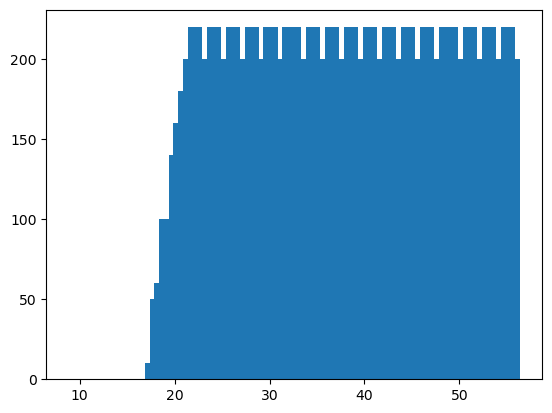

In [131]:
new_S.plot.hist(bins=target_coords);

In [132]:
init = xr.open_dataset(filepath + '10km_channel_init.nc')

In [133]:
from xhistogram.xarray import histogram
histogram(ss_ds_output.salinity.isel(Time=0),bins=target_coords) - histogram(avg_ds_output.salinity.isel(Time=0),bins=target_coords)
histogram(ss_ds_output.salinity.isel(Time=0),bins=target_coords) - histogram(init.salinity,bins=target_coords)

<xarray.DataArray 'histogram_salinity' (salinity_bin: 95)> Size: 760B
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])
Coordinates:
  * salinity_bin  (salinity_bin) float64 760B 9.11 9.61 10.11 ... 55.61 56.11

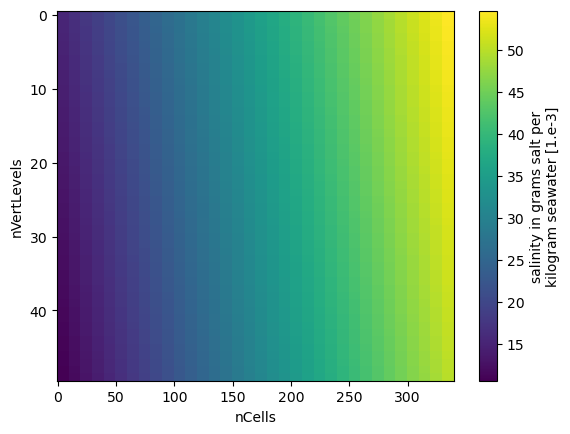

In [134]:
ss_ds_output.salinity.isel(Time=0).plot(y='nVertLevels')
plt.gca().invert_yaxis()
# is salinity set at the surface only or for the full domain?

Text(0.5, 0.98, 'Init file; $\\Delta s =$0.5')

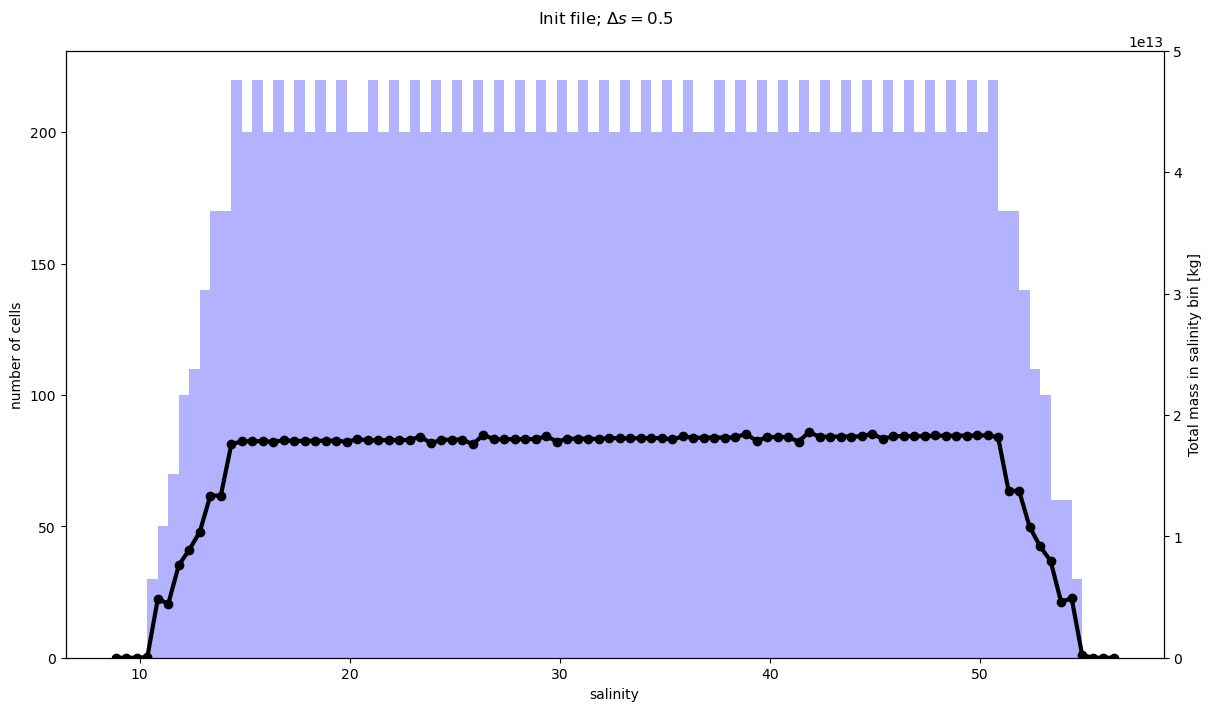

In [135]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, constrained_layout=True, figsize=(12,7))

init.salinity.plot.hist(ax=ax1, bins=target_coords,alpha=0.3, color='blue', label ='cell count');
ax1.set_ylabel('number of cells')

ax2 = ax1.twinx()
bin_centers = 0.5 * (target_coords[:-1] + target_coords[1:])
ax2.plot(target_coords, mass_transform.sum('nCells').isel(Time=0), color='black', linewidth=3, marker='o', label = 'mass')

ax2.set_ylim(0,5e13)
ax2.set_ylabel('Total mass in salinity bin [kg]')
fig.suptitle(r'Init file; $\Delta s =$'+ str(target_coord_spacing))

In [136]:
target_coords

array([ 8.86026721,  9.36026721,  9.86026721, 10.36026721, 10.86026721,
       11.36026721, 11.86026721, 12.36026721, 12.86026721, 13.36026721,
       13.86026721, 14.36026721, 14.86026721, 15.36026721, 15.86026721,
       16.36026721, 16.86026721, 17.36026721, 17.86026721, 18.36026721,
       18.86026721, 19.36026721, 19.86026721, 20.36026721, 20.86026721,
       21.36026721, 21.86026721, 22.36026721, 22.86026721, 23.36026721,
       23.86026721, 24.36026721, 24.86026721, 25.36026721, 25.86026721,
       26.36026721, 26.86026721, 27.36026721, 27.86026721, 28.36026721,
       28.86026721, 29.36026721, 29.86026721, 30.36026721, 30.86026721,
       31.36026721, 31.86026721, 32.36026721, 32.86026721, 33.36026721,
       33.86026721, 34.36026721, 34.86026721, 35.36026721, 35.86026721,
       36.36026721, 36.86026721, 37.36026721, 37.86026721, 38.36026721,
       38.86026721, 39.36026721, 39.86026721, 40.36026721, 40.86026721,
       41.36026721, 41.86026721, 42.36026721, 42.86026721, 43.36

Text(0, 0.5, 'Mass [kg]')

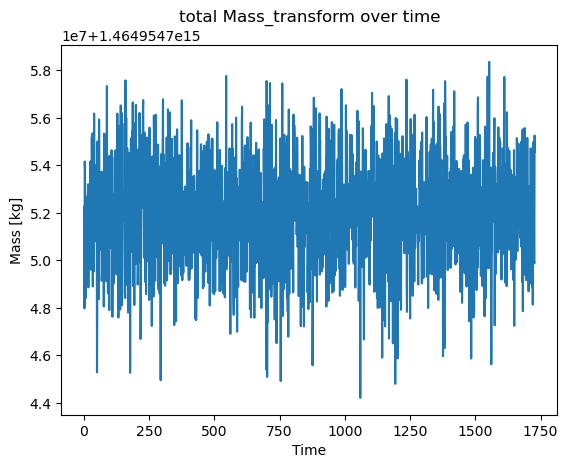

In [137]:
mass_transform.sum(dim=['nCells','salinity']).plot()
plt.title('total Mass_transform over time')
plt.ylabel('Mass [kg]')

Text(0.5, 1.0, 'Total mass along an isossurface over time')

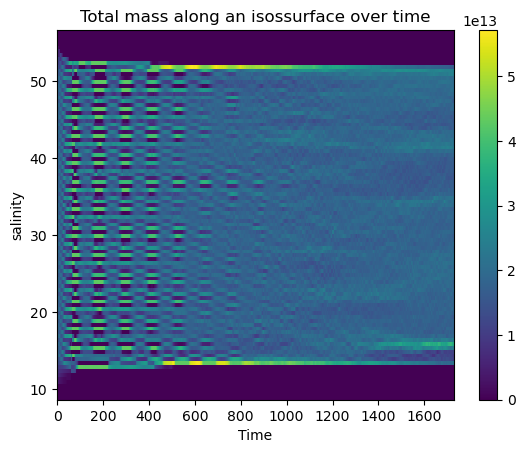

In [138]:
mass_transform.sum(dim='nCells').plot(y='salinity')
plt.title('Total mass along an isossurface over time')

In [139]:
np.unique(mesh.yCell)

array([ 17320.50807569,  25980.76211353,  34641.01615138,  43301.27018922,
        51961.52422707,  60621.77826491,  69282.03230276,  77942.2863406 ,
        86602.54037844,  95262.79441629, 103923.04845413, 112583.30249198,
       121243.55652982, 129903.81056767, 138564.06460551, 147224.31864335,
       155884.5726812 , 164544.82671904, 173205.08075689, 181865.33479473,
       190525.58883258, 199185.84287042, 207846.09690827, 216506.35094611,
       225166.60498395, 233826.8590218 , 242487.11305964, 251147.36709749,
       259807.62113533, 268467.87517318, 277128.12921102, 285788.38324886,
       294448.63728671, 303108.89132455])

In [140]:
25980.76211353 - 17320.50807569

8660.25403784

In [141]:
34641.01615138 - 25980.76211353

8660.254037849998

In [151]:
ss_ds_output.potentialDensity.max()

<xarray.DataArray 'potentialDensity' ()> Size: 8B
array(1011.51898193)

<a list of 0 text.Text objects>

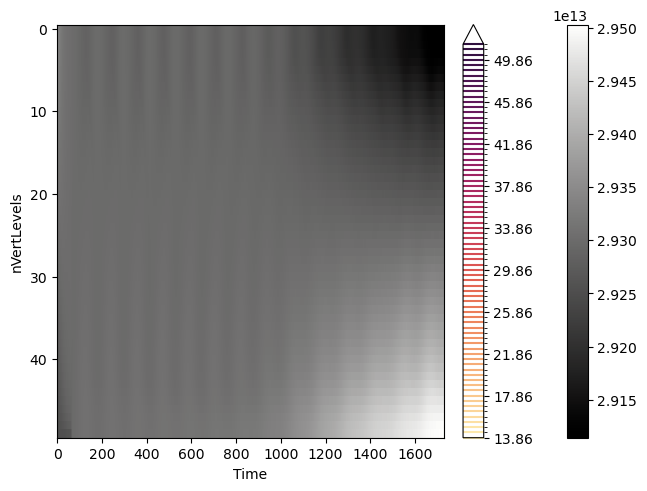

In [147]:
fig, ax = plt.subplots(nrows=1,ncols=1, constrained_layout=True)
mass.sum(dim='nCells').plot(y='nVertLevels',cmap=cmo.gray)
c = ss_ds_output.density.mean(dim='nCells').plot.contour(levels = target_coords[10:-10], y = 'nVertLevels', cmap = cmo.matter)
ax.invert_yaxis()
fig.colorbar(c, ax =ax)
ax.clabel(c)

<a list of 42 text.Text objects>

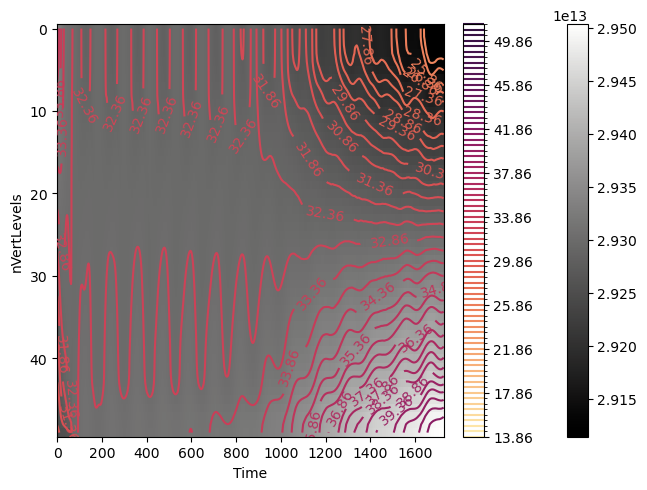

In [142]:
fig, ax = plt.subplots(nrows=1,ncols=1, constrained_layout=True)
mass.sum(dim='nCells').plot(y='nVertLevels',cmap=cmo.gray)
c = ss_ds_output.salinity.mean(dim='nCells').plot.contour(levels = target_coords[10:-10], y = 'nVertLevels', cmap = cmo.matter)
ax.invert_yaxis()
fig.colorbar(c, ax =ax)
ax.clabel(c)

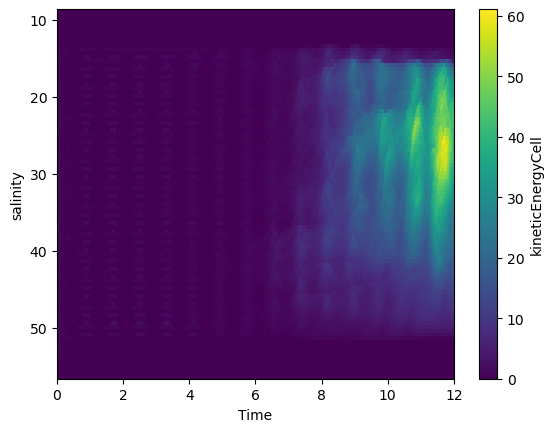

In [143]:
ke_transform = avg_ds_grid.transform(avg_ds_output.kineticEnergyCell,
                                     'Z',
                                     target_coords,
                                     method = 'linear',
                                     target_data = avg_ds_output.salinity)

ke_transform.sum('nCells').plot(y='salinity')
# avg_ds_output.kineticEnergyCell.sum('nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

Text(0.5, 0.98, 'Mean budget term along isohaline surfaces over time')

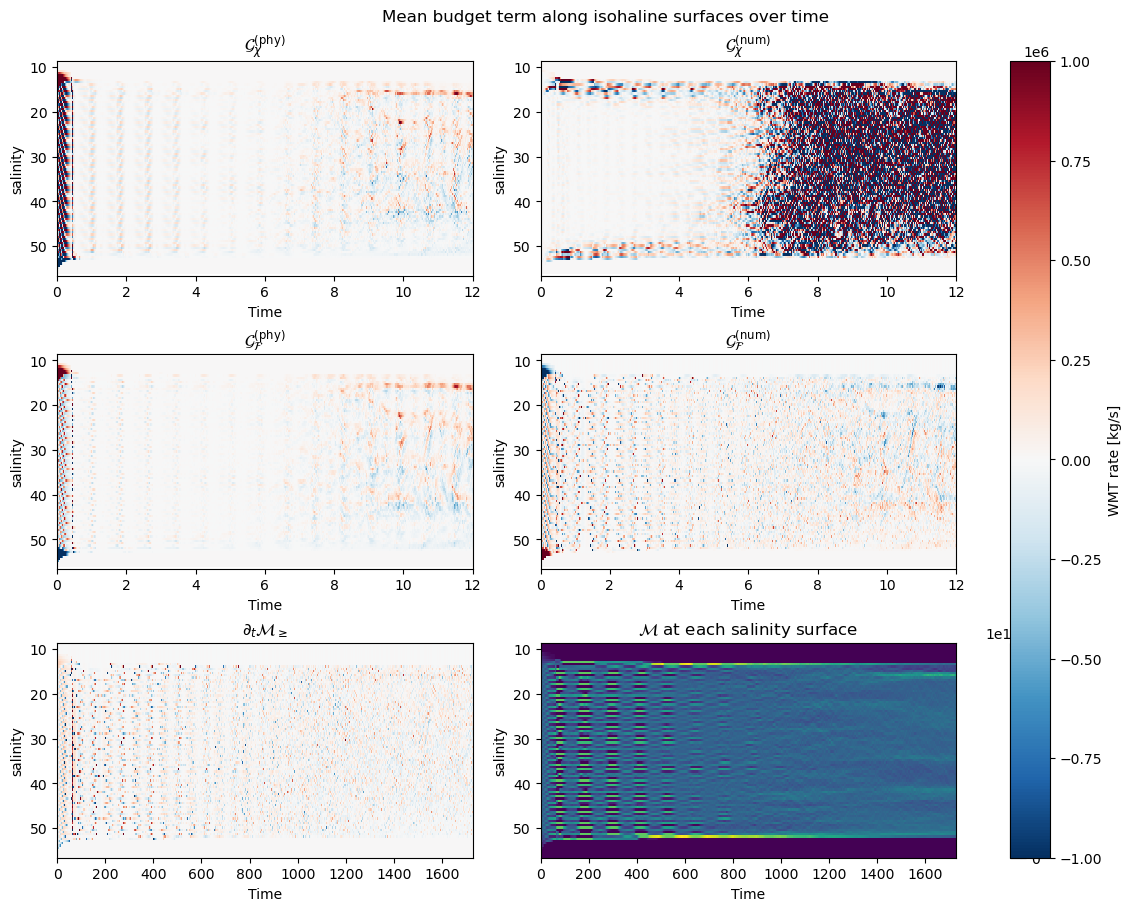

In [144]:
fig, ax = plt.subplots(nrows=3,ncols=2,constrained_layout=True,figsize=(12,9))

G_phy_comp_ds.G_chi_phy.mean(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
G_phy_comp_ds.G_chi_num.mean(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

G_phy_comp_ds.G_F_phy_center.mean(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
G_F_num.mean(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

c = dM_dt.mean(dim='nCells').plot(ax=ax[2,0], y='salinity', vmin=-1e6, vmax=1e6, cmap ='RdBu_r',add_colorbar=False)
ax[2,0].set_title(r'$\partial_t \mathcal{M}_\geq$')

mass_transform.sum(dim='nCells').plot(ax=ax[2,1], y='salinity')
ax[2,1].set_title(r'$\mathcal{M}$ at each salinity surface')

fig.colorbar(c, ax=ax, label='WMT rate [kg/s]')

for i in range(0,3):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

fig.suptitle('Mean budget term along isohaline surfaces over time')

Text(0.5, 1.0, 'Mean vertical velocity at each isohline surface over time')

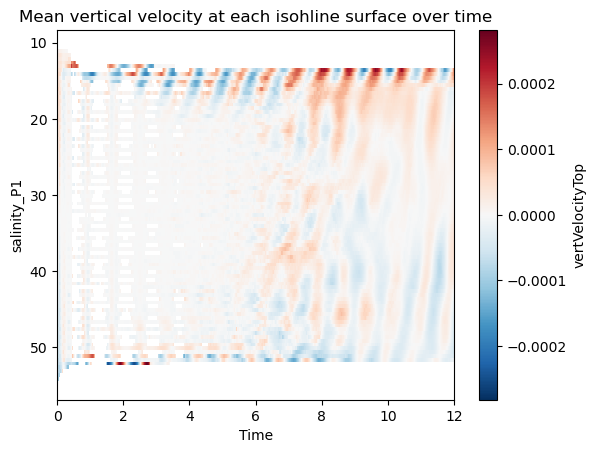

In [145]:
remapped_vertVelocity = avg_ds_grid.transform(avg_ds_output.vertVelocityTop,
                                              'Z',
                                              target_coords_P1,
                                              method = 'linear',
                                              target_data = avg_ds_output.salinity_P1)
remapped_vertVelocity.mean(dim='nCells').plot(y='salinity_P1')
plt.gca().invert_yaxis()
plt.title('Mean vertical velocity at each isohline surface over time')

Text(0.5, 1.0, 'Time-averaged WMT budget for $\\mathcal{M}_{\\geq}$')

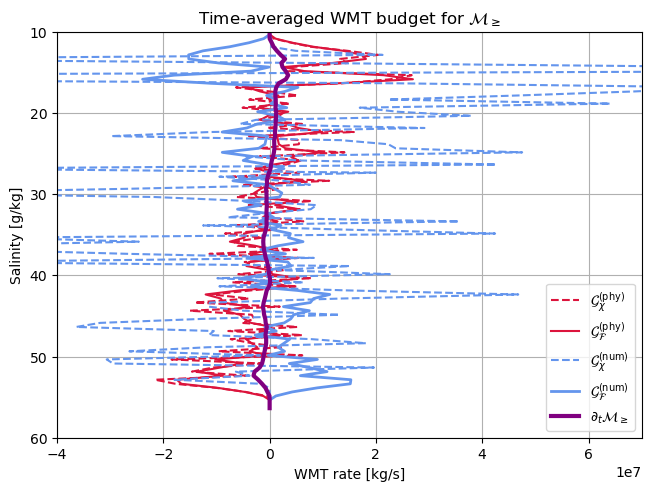

In [146]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)

# G_phy
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_chi_phy.plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$', 
                                                            linestyle='dashed', color='crimson')
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_F_phy_center.plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', color = 'crimson')

# G_num
G_phy_comp_ds.mean(dim='Time').sum('nCells').G_chi_num.plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$', 
                                                            linestyle='dashed',color='cornflowerblue')
G_F_num.mean(dim='Time').sum('nCells').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$',linewidth = 2, color='cornflowerblue')
# ds_dt.mean(dim='Time').sum('nCells').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

# dM/dt
dM_dt.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\partial_t \mathcal{M}_{\geq}$', color='purple',linewidth = 3)

ax.grid()
ax.set_ylim(10,60)
ax.set_xlim(-4e7, 7e7)
ax.legend()
ax.invert_yaxis()
ax.set_xlabel('WMT rate [kg/s]')
ax.set_ylabel('Salinity [g/kg]')
ax.set_title(r'Time-averaged WMT budget for $\mathcal{M}_{\geq}$')

# dM/dt does not go to 0 at salinity = minimum. please just be numerical floating point error or something...

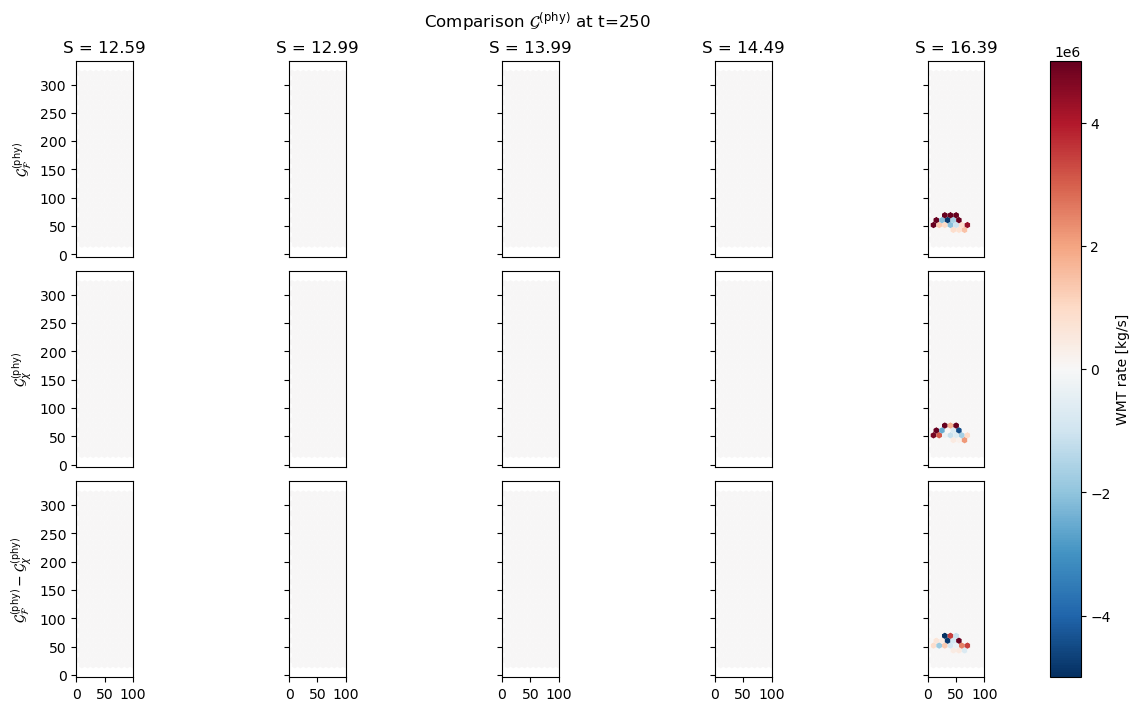

In [339]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([4,8,18,23,42]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).isel(Time=250), 
                          cmap = 'RdBu_r', vmin= -5e6, vmax = 5e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison $\mathcal{G}^{\text{(phy)}}$ at t=250');

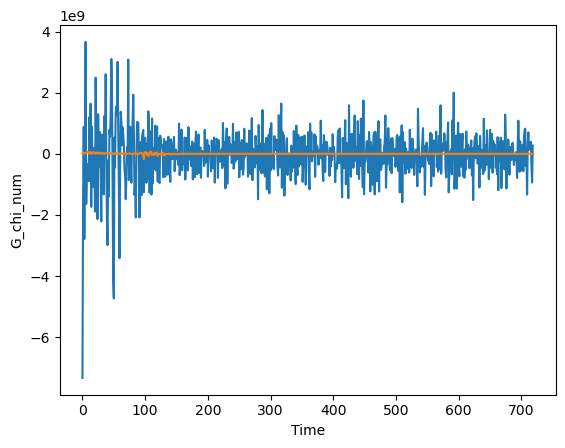

In [314]:
G_F_num.sum(dim=['salinity','nCells']).plot()
G_phy_comp_ds.G_chi_num.sum(dim=['salinity','nCells']).plot()

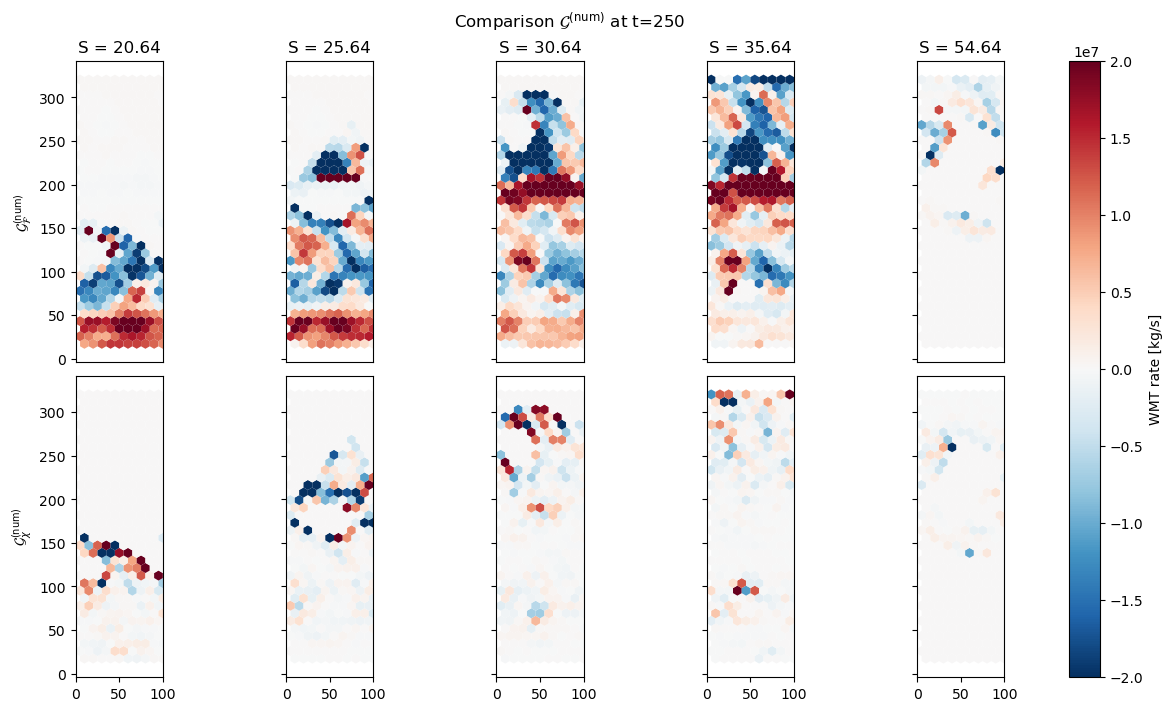

In [37]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=2, ncols=5, constrained_layout=True, figsize=(12,7))

# G_phy_comp_ds['G_F_num'] = G_F_num
# G_phy_comp_ds['diff_num'] = G_phy_comp_ds.G_F_num - G_phy_comp_ds.G_chi_num

isosurface_idx = np.array([8,13,18,23,42]) 
row_variables = ['G_F_num' ,'G_chi_num', 'diff_num']

for j in range(0,5):        
        c = mosaic.polypcolor(ax[0,j], descriptor,G_F_num.isel(salinity = isosurface_idx[j]).isel(Time=250), 
                          cmap = 'RdBu_r', vmin= -2e7, vmax = 2e7)
        d = mosaic.polypcolor(ax[1,j], descriptor, G_phy_comp_ds['G_chi_num'].isel(salinity = isosurface_idx[j]).isel(Time=250), 
                          cmap = 'RdBu_r', vmin= -2e7, vmax = 2e7)

# format
for i in range(0,2):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[1,j].set_xticks(np.arange(0,150000,50000))
        ax[1,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(num)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison $\mathcal{G}^{\text{(num)}}$ at t=250');

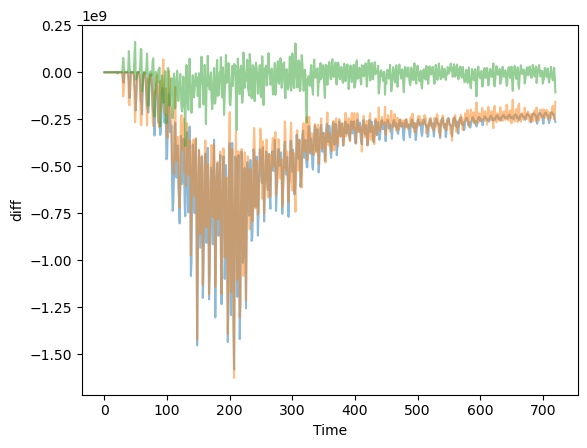

In [46]:
G_phy_comp_ds.G_F_phy_center.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds.G_chi_phy.sum(dim=['nCells','salinity']).plot(alpha=0.5)
G_phy_comp_ds['diff'].sum(dim=['nCells','salinity']).plot(alpha=0.5)

In [48]:
G_phy_comp_ds.G_F_phy_center.sum()

<xarray.DataArray 'G_F_phy_center' ()> Size: 8B
array(-2.59688949e+11)

In [50]:
ds_output.salinitySurfaceFluxTendency.sum()

<xarray.DataArray 'salinitySurfaceFluxTendency' ()> Size: 4B
array(0., dtype=float32)

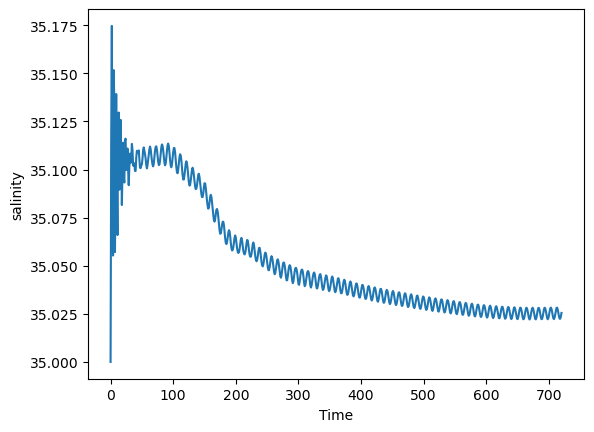

In [54]:
salinity_ts = ds_output.salinity.mean(dim=['nCells','nVertLevels'])
salinity_ts.plot()